# humidity

In [78]:
import pandas as pd

In [79]:
df_district = pd.read_csv('../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv')

df_district = df_district.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'humidity']
df_district = df_district[desired_colmn]

df_district = df_district.dropna()

df_district.head()

,day,month,year,humidity
6,7,1,1980,52.9
386,21,1,1981,80.0
731,1,1,1982,82.5
732,2,1,1982,70.3
733,3,1,1982,8.2


Date range: 2014-01-01 to 2024-12-31


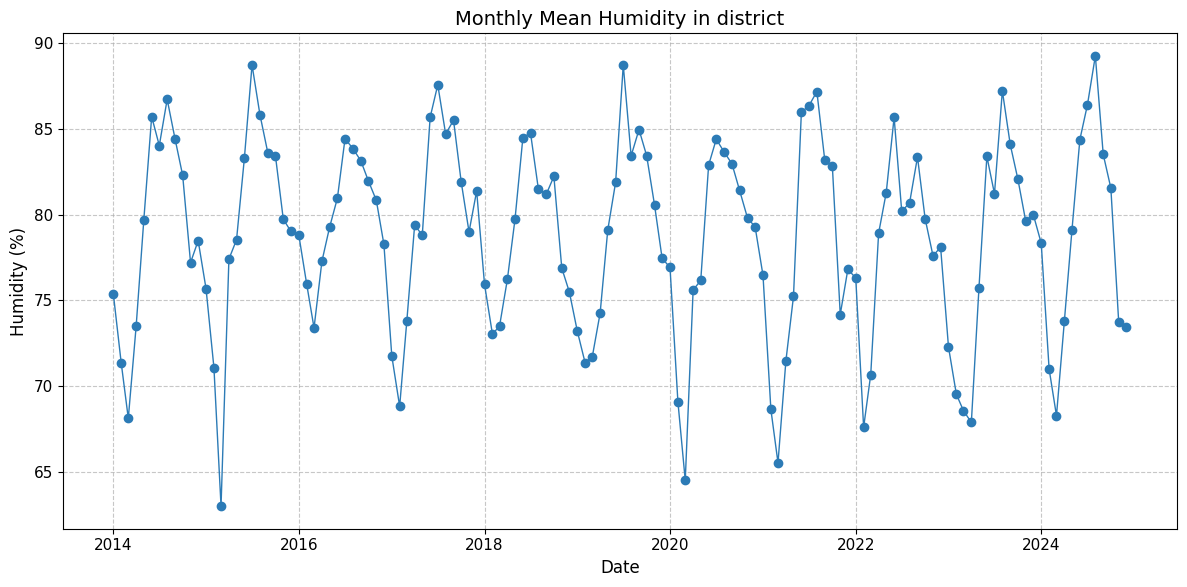

In [80]:
import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])

# # show date range
# min_date = df_district['date'].min()
# max_date = df_district['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")

# 2010-2024 dile 83% r2 lightgbm
# 2014- 2024 dile 82% R2
# 2018-2024 dile 52% R2 xgboost

# filter data for custom date range: 2020 to 2024
df_district = df_district[
    (df_district['date'] >= '2014-01-01') & (df_district['date'] <= '2024-12-31')
]
custom_range_df = df_district.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()

df_district['date'] = pd.to_datetime(df_district['date'])
df_district.set_index('date', inplace=True)

df_monthly_hum = df_district['humidity'].resample('MS').mean()
# Fill missing gaps using linear interpolation (common for weather data)
df_monthly_hum = df_monthly_hum.interpolate(method='linear')

print(f"Date range: {min_date.date()} to {max_date.date()}")

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(df_monthly_hum, marker='o', linestyle='-', color='#2c7bb6', linewidth=1)
plt.title('Monthly Mean Humidity in district', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) 

# pchip: Piecewise Cubic Hermite Interpolating Polynomial

df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_hum.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [82]:
df_monthly_hum.head()

,date,humidity
0,2014-01-01,75.390323
1,2014-02-01,71.367857
2,2014-03-01,68.119355
3,2014-04-01,73.510000
4,2014-05-01,79.670968


In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['humidity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


## RF hum

In [84]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Humidity Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Humidity Prediction (Test) ===
R²          : 0.7559
RMSE        : 2.549 °C
MSE         : 6.4958
Accuracy (± tolerance):
  ±0.5 °C : 14.81%
  ±1.0 °C : 33.33%
  ±2.0 °C : 51.85%
  ±3.0 °C : 74.07%

=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.7325  (±0.0826)
Scores  : [0.5804 0.7149 0.8116 0.7649 0.7905]

=== Feature Importances (Top 10) ===
 feature  importance
   sin_1    0.686214
   cos_1    0.187784
   cos_3    0.060695
   sin_2    0.039610
year_val    0.016714
   sin_3    0.005796
   cos_2    0.003188


## XGBoost hum

In [85]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.7621
xgboost_MSE  : 6.3293
xgboost_RMSE : 2.5158
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  7.41%
  ±1.0°C : 25.93%
  ±2.0°C : 55.56%
  ±3.0°C : 74.07%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.5939  |  Std : 0.1299

==== Top Feature Importances ====
 feature  importance
   sin_1    0.328842
   sin_2    0.224095
   cos_1    0.200081
   cos_2    0.082597
   cos_3    0.073602
   sin_3    0.057727
year_val    0.033056


## light gbm hum

In [86]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) ====
LGB_R^2  : 0.7448
LGB_MSE  : 6.7894
LGB_RMSE : 2.6056
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 11.11%
  ±1.0°C : 29.63%
  ±2.0°C : 44.44%
  ±3.0°C : 66.67%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.7118  |  Std : 0.0875

==== Top Feature Importances ====
 feature   importance
   sin_1 59168.617675
   cos_1 25290.456364
year_val 13178.760358
   sin_2 13150.874384
   sin_3  9287.145415
   cos_3  6331.959545
   cos_2  3549.501578


## cat boost hum

In [87]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.7510
CatBoost_MSE  : 6.6258
CatBoost_RMSE : 2.5741
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 14.81%
  ±1.0°C : 33.33%
  ±2.0°C : 40.74%
  ±3.0°C : 70.37%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.6965  |  Std : 0.0661

==== Top Feature Importances ====
 feature  importance
   sin_1   47.180050
   cos_1   17.575777
   sin_2   10.404236
year_val    7.305635
   sin_3    6.018552
   cos_2    5.861564
   cos_3    5.654186


## comparision humidity

In [88]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2    CV R2      MSE     RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.755880 0.732458 6.495787 2.548683       14.814815       33.333333       51.851852       74.074074
      XGBoost 0.762136 0.593911 6.329323 2.515814        7.407407       25.925926       55.555556       74.074074
     LightGBM 0.744847 0.711766 6.789361 2.605640       11.111111       29.629630       44.444444       66.666667
     CatBoost 0.750996 0.696502 6.625755 2.574054       14.814815       33.333333       40.740741       70.370370


In [89]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
0  Random Forest  0.755880  0.732458  0.023422         0.836354        Robust
3       CatBoost  0.750996  0.696502  0.054494         0.601441        Robust
1        XGBoost  0.762136  0.593911  0.168226         0.450000  Overfit Risk
2       LightGBM  0.744847  0.711766  0.033081         0.449323        Robust


## predicting with best model for two years humidity

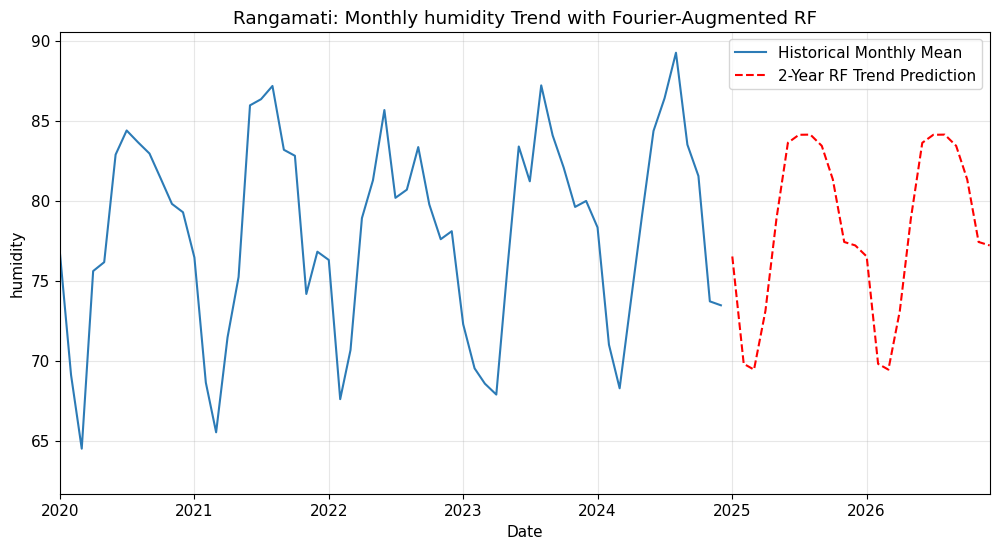

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_hum.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['humidity']

# 4. Train Random Forest [cite: 145, 146]
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_hum = rf.predict(future_df[FEATURES])


# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_hum, label='2-Year RF Trend Prediction', linestyle='--', color='red')
plt.title('Rangamati: Monthly humidity Trend with Fourier-Augmented RF')
plt.xlabel('Date')
plt.ylabel('humidity')
plt.legend()
plt.grid(True, alpha=0.3)
# Set the start date to Jan 1st, 2023
plt.xlim(pd.Timestamp('2020-01-01'), future_dates.max())
plt.show()

<>:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:24: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:24: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_13972\2654542030.py:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')
C:\Users\User\AppData\Local\Temp\ipykernel_13972\2654542030.py:24: SyntaxWarning: "\p" is 

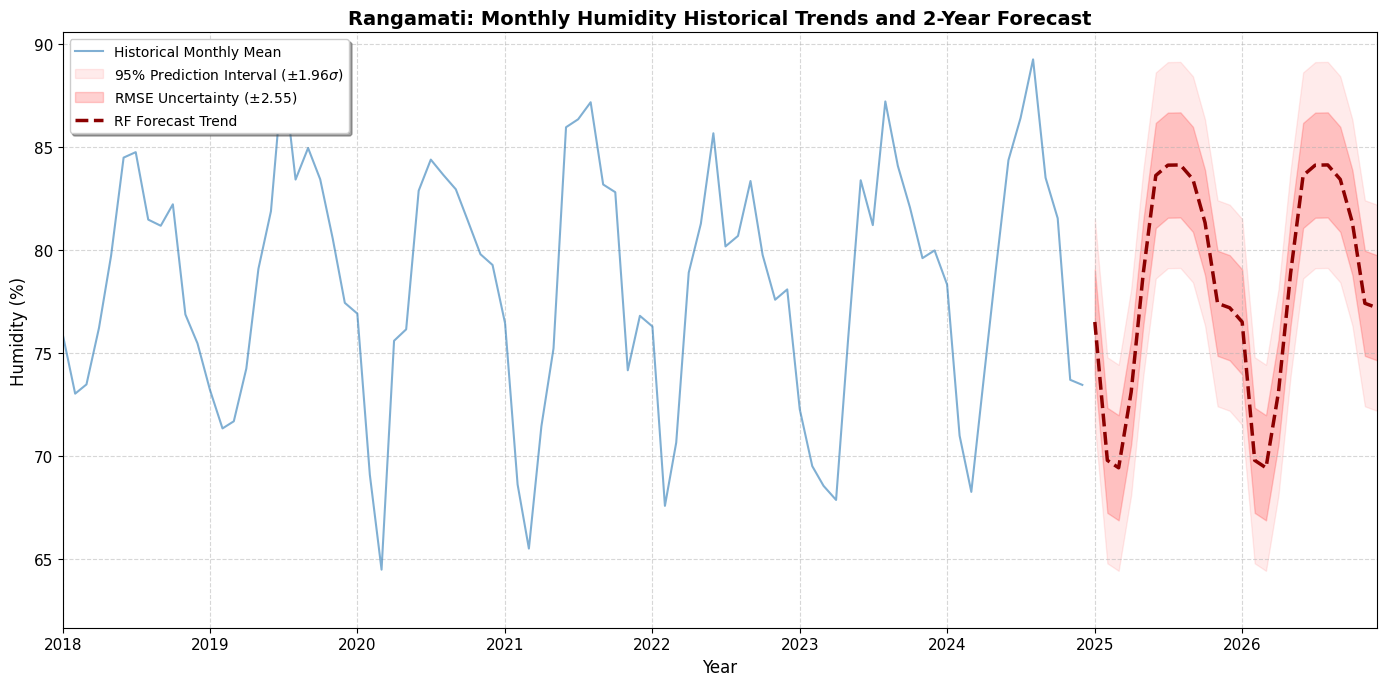

In [91]:
# 5. Predict 2 Years Future with Empirical Validation
mean_preds = rf.predict(future_df[FEATURES])

best_model_rmse = 2.548683 
upper_95 = mean_preds + (1.96 * best_model_rmse)
lower_95 = mean_preds - (1.96 * best_model_rmse)
upper_68 = mean_preds + best_model_rmse
lower_68 = mean_preds - best_model_rmse

# 2. Setup the Plot
plt.figure(figsize=(14, 7))

# 3. Plot Historical Data (The Context)
# Ensure df_features['date'] is in datetime format
plt.plot(df_features['date'], y, label='Historical Monthly Mean', 
         color='#2c7bb6', alpha=0.6, linewidth=1.5)

# 4. Plot the 95% Confidence Interval (The Outer Cloud)
plt.fill_between(future_dates, lower_95, upper_95, 
                 color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')

# 5. Plot the 68% Confidence Interval (The RMSE Cloud)
plt.fill_between(future_dates, lower_68, upper_68, 
                 color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${best_model_rmse:.2f})')

# 6. Plot the Future Prediction Mean (The Trend)
plt.plot(future_dates, mean_preds, label='RF Forecast Trend', 
         linestyle='--', color='darkred', lw=2.5)

# 7. Journal Formatting & Aesthetics
plt.title('Rangamati: Monthly Humidity Historical Trends and 2-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)

# Set the x-axis to start slightly before the forecast for better perspective
# Adjust '2018-01-01' to whatever date makes your historical trend visible
plt.xlim(pd.Timestamp('2018-01-01'), future_dates.max()) 

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

In [92]:
# create the dataframe of the predicted values of 2025 and 2026
df_predictions_humidity = pd.DataFrame({
    'date': future_dates,
    'predicted_humidity': predictions_hum
})


In [93]:
df_predictions_humidity

,date,predicted_humidity
0,2025-01-01,76.514579
1,2025-02-01,69.806988
2,2025-03-01,69.444449
3,2025-04-01,73.114804
4,2025-05-01,78.882099
5,2025-06-01,83.617509
6,2025-07-01,84.117355
7,2025-08-01,84.128398
8,2025-09-01,83.428400
9,2025-10-01,81.332769


# temperature

In [94]:
import pandas as pd

In [95]:
df_district = pd.read_csv('../1980-2024-dataset/Bagerhat_historical_weather_1980_2024.csv')

df_district = df_district.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'temperature(degree C)']
df_district = df_district[desired_colmn]

df_district = df_district.dropna()

df_district.head()

,day,month,year,temperature(degree C)
0,1,1,1980,21.7
1,2,1,1980,20.8
2,3,1,1980,23.0
3,4,1,1980,22.3
4,5,1,1980,22.1


Date range: 2014-01-01 to 2024-12-31


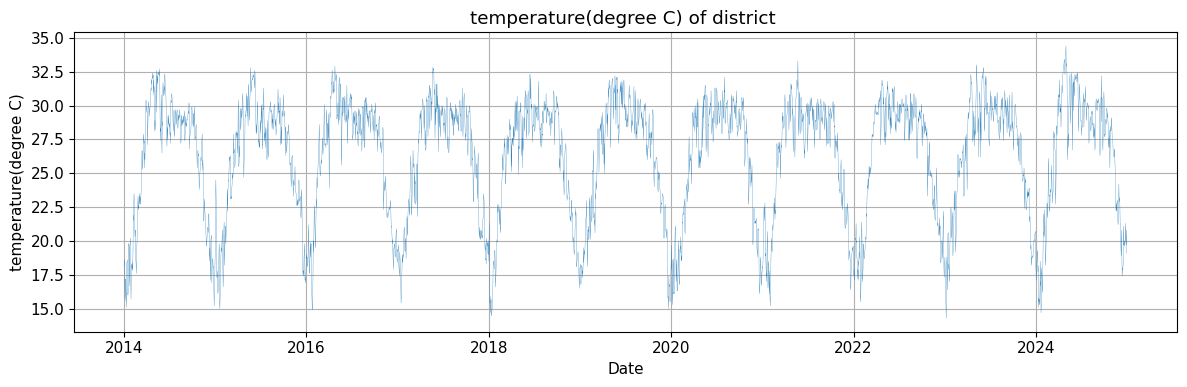

In [96]:
import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])

# # show date range
# min_date = df_district['date'].min()
# max_date = df_district['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")


# 1980-2024 dile 92% R2 xgboost
# 2010-2024 dile 96.7% r2 rf
# 2014/2024 filr 95% r2 xgboost
# filter data for custom date range: 2020 to 2024
df_district = df_district[
    (df_district['date'] >= '2014-01-01') & (df_district['date'] <= '2024-12-31')
]
custom_range_df = df_district.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()
print(f"Date range: {min_date.date()} to {max_date.date()}")

# plot daily temperature time series
plt.figure(figsize=(12, 4))
plt.plot(df_district['date'], df_district['temperature(degree C)'], linewidth=0.2)
plt.xlabel('Date')
plt.ylabel('temperature(degree C)')
plt.title('temperature(degree C) of district ')
plt.grid(True)
plt.tight_layout()
plt.show()

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna() # Fill missing gaps using linear interpolation (common for weather data)

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_temp.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['temperature(degree C)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


## RF temp

In [99]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Humidity Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Humidity Prediction (Test) ===
R²          : 0.9326
RMSE        : 1.050 °C
MSE         : 1.1028
Accuracy (± tolerance):
  ±0.5 °C : 29.63%
  ±1.0 °C : 59.26%
  ±2.0 °C : 96.30%
  ±3.0 °C : 100.00%

=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.7928  (±0.1570)
Scores  : [0.505  0.765  0.8332 0.9405 0.9203]

=== Feature Importances (Top 10) ===
 feature  importance
   cos_1    0.763659
   sin_1    0.103390
   sin_2    0.083536
   sin_3    0.018245
   cos_3    0.013826
   cos_2    0.013240
year_val    0.004103


## XGBoost temp

In [100]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.9601
xgboost_MSE  : 0.6532
xgboost_RMSE : 0.8082
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 48.15%
  ±1.0°C : 74.07%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.9606  |  Std : 0.0086

==== Top Feature Importances ====
 feature  importance
   cos_1    0.534347
   sin_2    0.177131
   sin_1    0.138914
   sin_3    0.084572
   cos_3    0.034908
   cos_2    0.024982
year_val    0.005146


## light gbm temp

In [101]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) ====
LGB_R^2  : 0.9584
LGB_MSE  : 0.6799
LGB_RMSE : 0.8245
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 48.15%
  ±1.0°C : 74.07%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.9620  |  Std : 0.0112

==== Top Feature Importances ====
 feature   importance
   cos_1 30449.602225
   sin_1 11932.161401
   sin_2  5965.043584
   sin_3  4640.441839
   cos_2  3521.615519
   cos_3  2170.755985
year_val   903.412942


## cat boost temp

In [102]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.9576
CatBoost_MSE  : 0.6940
CatBoost_RMSE : 0.8331
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 55.56%
  ±1.0°C : 77.78%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.9611  |  Std : 0.0126

==== Top Feature Importances ====
 feature  importance
   cos_1   63.927451
   sin_1   10.779232
   sin_2    9.267459
   sin_3    6.107366
   cos_3    4.438395
   cos_2    3.864398
year_val    1.615698


## comparision temp

In [103]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2    CV R2      MSE     RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.932569 0.792805 1.102761 1.050124       29.629630       59.259259       96.296296           100.0
      XGBoost 0.960057 0.960603 0.653221 0.808221       48.148148       74.074074      100.000000           100.0
     LightGBM 0.958428 0.961956 0.679855 0.824533       48.148148       74.074074      100.000000           100.0
     CatBoost 0.957562 0.961110 0.694032 0.833086       55.555556       77.777778      100.000000           100.0


In [104]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
1        XGBoost  0.960057  0.960603  0.000546         0.978000        Robust
3       CatBoost  0.957562  0.961110  0.003549         0.951183        Robust
2       LightGBM  0.958428  0.961956  0.003528         0.947418        Robust
0  Random Forest  0.932569  0.792805  0.139763         0.000000  Overfit Risk


## predicting with best model for two years temperature

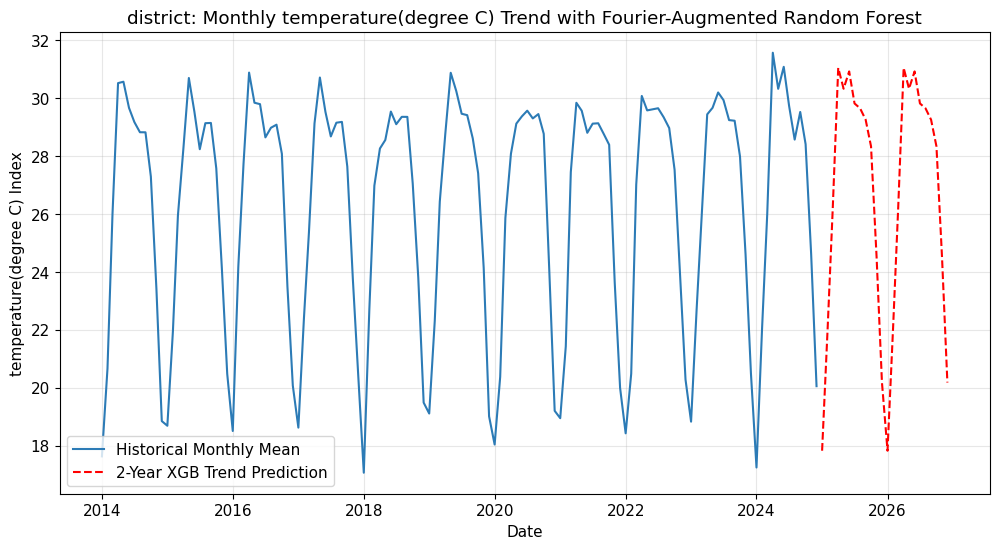

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['temperature(degree C)']

# 4. Train Random Forest [cite: 145, 146]
xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_temp = xgb_model.predict(future_df[FEATURES])

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_temp, label='2-Year XGB Trend Prediction', linestyle='--', color='red')
plt.title('district: Monthly temperature(degree C) Trend with Fourier-Augmented Random Forest')
plt.xlabel('Date')
plt.ylabel('temperature(degree C) Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_13972\3539658560.py:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')
C:\Users\User\AppData\Local\Temp\ipykernel_13972\3539658560.py:25: SyntaxWarning: "\p" is 

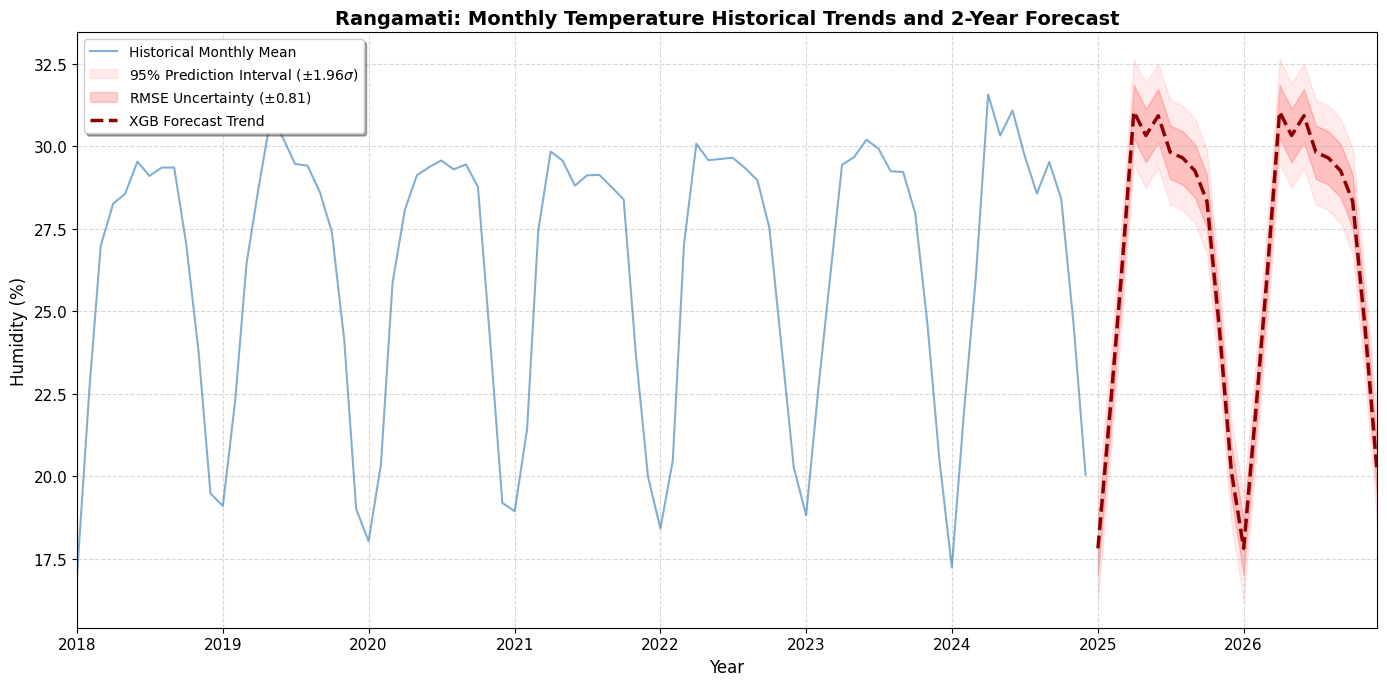

In [106]:
# 5. Predict 2 Years Future with Empirical Validation
mean_preds = xgb_model.predict(future_df[FEATURES])

# 1. Define the Uncertainty Bounds (Based on your XGB RMSE)
best_model_rmse = 0.808083 
upper_95 = mean_preds + (1.96 * best_model_rmse)
lower_95 = mean_preds - (1.96 * best_model_rmse)
upper_68 = mean_preds + best_model_rmse
lower_68 = mean_preds - best_model_rmse

# 2. Setup the Plot
plt.figure(figsize=(14, 7))

# 3. Plot Historical Data (The Context)
# Ensure df_features['date'] is in datetime format
plt.plot(df_features['date'], y, label='Historical Monthly Mean', 
         color='#2c7bb6', alpha=0.6, linewidth=1.5)

# 4. Plot the 95% Confidence Interval (The Outer Cloud)
plt.fill_between(future_dates, lower_95, upper_95, 
                 color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')

# 5. Plot the 68% Confidence Interval (The RMSE Cloud)
plt.fill_between(future_dates, lower_68, upper_68, 
                 color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${best_model_rmse:.2f})')

# 6. Plot the Future Prediction Mean (The Trend)
plt.plot(future_dates, mean_preds, label='XGB Forecast Trend', 
         linestyle='--', color='darkred', lw=2.5)

# 7. Journal Formatting & Aesthetics
plt.title('Rangamati: Monthly Temperature Historical Trends and 2-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)

# Set the x-axis to start slightly before the forecast for better perspective
# Adjust '2018-01-01' to whatever date makes your historical trend visible
plt.xlim(pd.Timestamp('2018-01-01'), future_dates.max()) 

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

In [107]:
df_predictions_temp = pd.DataFrame({
    'date': future_dates,
    'predicted_temp': predictions_temp
})

df_predictions_temp

,date,predicted_temp
0,2025-01-01,17.821377
1,2025-02-01,22.059145
2,2025-03-01,26.126484
3,2025-04-01,31.050207
4,2025-05-01,30.328499
5,2025-06-01,30.927353
6,2025-07-01,29.820646
7,2025-08-01,29.651806
8,2025-09-01,29.259247
9,2025-10-01,28.338671


# Solar radiation

In [108]:
import pandas as pd

In [109]:
df_district = pd.read_csv('../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv')

df_district = df_district.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'solar_radiation']
df_district = df_district[desired_colmn]

df_district = df_district.dropna()

df_district.head()

,day,month,year,solar_radiation
12054,1,1,2013,192.3
12055,2,1,2013,182.9
12056,3,1,2013,66.2
12057,4,1,2013,181.8
12058,5,1,2013,197.2


Date range: 2014-01-01 to 2024-12-31


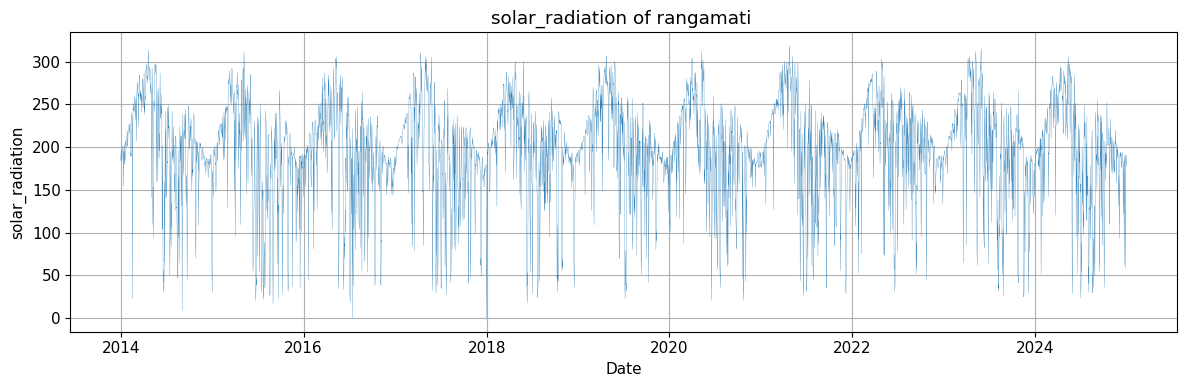

In [110]:
import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])

# # show date range
# min_date = df_district['date'].min()
# max_date = df_district['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")

# 2010-2024 dile 83% r2 lightgbm
# 2014- 2024 dile 82% R2
# 2018-2024 dile 52% R2 xgboost

# filter data for custom date range: 2020 to 2024
df_district = df_district[
    (df_district['date'] >= '2014-01-01') & (df_district['date'] <= '2024-12-31')
]
custom_range_df = df_district.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()
print(f"Date range: {min_date.date()} to {max_date.date()}")

# plot daily temperature time series
plt.figure(figsize=(12, 4))
plt.plot(df_district['date'], df_district['solar_radiation'], linewidth=0.2)
plt.xlabel('Date')
plt.ylabel('solar_radiation')
plt.title('solar_radiation of rangamati ')
plt.grid(True)
plt.tight_layout()
plt.show()

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_hum = df.set_index('date')['solar_radiation'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.dropna()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_hum.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['solar_radiation']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


## RF

In [113]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Humidity Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Humidity Prediction (Test) ===
R²          : 0.7067
RMSE        : 20.132 °C
MSE         : 405.3163
Accuracy (± tolerance):
  ±0.5 °C :  3.70%
  ±1.0 °C :  7.41%
  ±2.0 °C :  7.41%
  ±3.0 °C : 11.11%

=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.6606  (±0.1155)
Scores  : [0.5744 0.6528 0.8439 0.5121 0.7201]

=== Feature Importances (Top 10) ===
 feature  importance
   sin_1    0.801385
   cos_1    0.074434
   sin_2    0.049061
   sin_3    0.027491
year_val    0.024814
   cos_3    0.020442
   cos_2    0.002373


## XGB

In [114]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.8018
xgboost_MSE  : 273.9529
xgboost_RMSE : 16.5515
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  3.70%
  ±1.0°C :  7.41%
  ±2.0°C : 18.52%
  ±3.0°C : 29.63%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.5769  |  Std : 0.1387

==== Top Feature Importances ====
 feature  importance
   sin_1    0.315887
   cos_2    0.199860
   sin_2    0.143710
   cos_1    0.121768
   sin_3    0.116019
   cos_3    0.069482
year_val    0.033274


## light gbm

In [115]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) ====
LGB_R^2  : 0.7800
LGB_MSE  : 304.0311
LGB_RMSE : 17.4365
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  3.70%
  ±1.0°C : 11.11%
  ±2.0°C : 14.81%
  ±3.0°C : 29.63%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.6887  |  Std : 0.1334

==== Top Feature Importances ====
 feature   importance
   sin_1 2.268647e+06
year_val 5.545307e+05
   cos_1 5.271272e+05
   cos_2 4.690068e+05
   sin_2 4.344833e+05
   sin_3 3.843615e+05
   cos_3 2.443894e+05


## cat

In [116]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.7845
CatBoost_MSE  : 297.8057
CatBoost_RMSE : 17.2570
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  0.00%
  ±1.0°C :  0.00%
  ±2.0°C : 18.52%
  ±3.0°C : 22.22%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.6894  |  Std : 0.1192

==== Top Feature Importances ====
 feature  importance
   sin_1   52.184662
   sin_2   11.440716
   cos_1    8.611866
year_val    8.391361
   sin_3    7.349152
   cos_2    6.359516
   cos_3    5.662727


## comparision solar radiation

In [117]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2    CV R2        MSE      RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.706738 0.660642 405.316333 20.132470        3.703704        7.407407        7.407407       11.111111
      XGBoost 0.801785 0.576930 273.952896 16.551522        3.703704        7.407407       18.518519       29.629630
     LightGBM 0.780022 0.688710 304.031108 17.436488        3.703704       11.111111       14.814815       29.629630
     CatBoost 0.784526 0.689403 297.805741 17.257049        0.000000        0.000000       18.518519       22.222222


In [118]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
2       LightGBM  0.780022  0.688710  0.091312         0.841200        Robust
3       CatBoost  0.784526  0.689403  0.095123         0.760348        Robust
1        XGBoost  0.801785  0.576930  0.224855         0.516667  Overfit Risk
0  Random Forest  0.706738  0.660642  0.046096         0.452738        Robust


## predicting with best model for 2 yrs solar rad

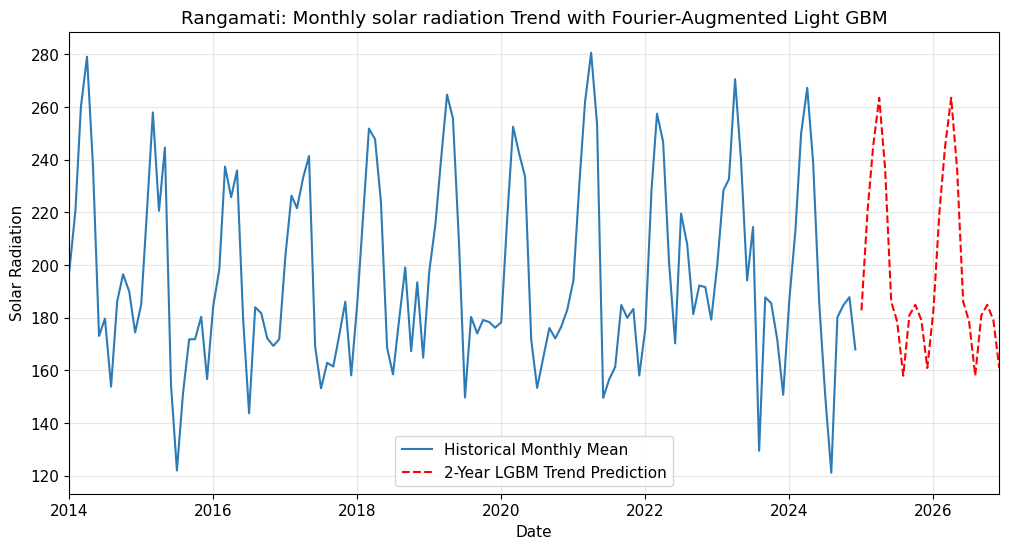

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_rad = df.set_index('date')['solar_radiation'].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_rad.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['solar_radiation']

# 4. Train Random Forest [cite: 145, 146]
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_solar = lgb_model.predict(future_df[FEATURES])

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_solar, label='2-Year LGBM Trend Prediction', linestyle='--', color='red')
plt.title('Rangamati: Monthly solar radiation Trend with Fourier-Augmented Light GBM')
plt.xlabel('Date')
plt.ylabel('Solar Radiation')
plt.legend()
plt.grid(True, alpha=0.3)
# Set the start date to Jan 1st, 2023
plt.xlim(pd.Timestamp('2014-01-01'), future_dates.max())
plt.show()

<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_13972\4239991250.py:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')
C:\Users\User\AppData\Local\Temp\ipykernel_13972\4239991250.py:25: SyntaxWarning: "\p" is 

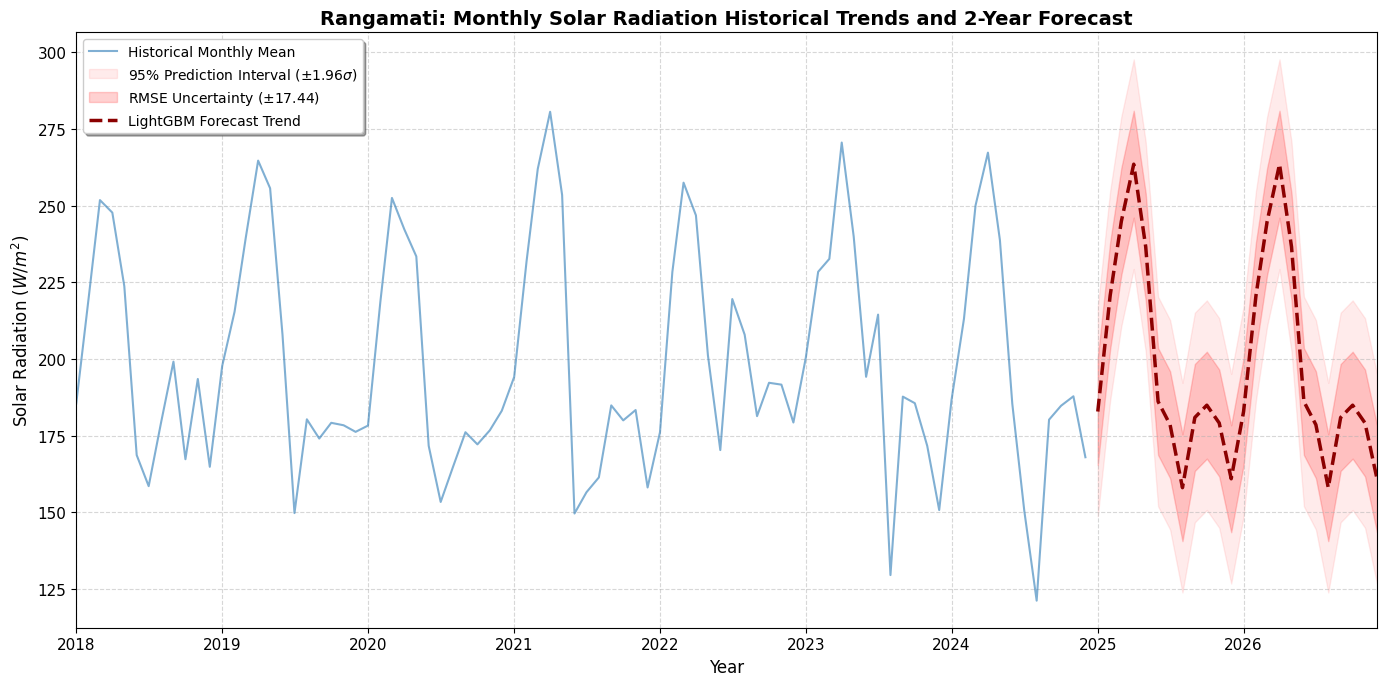

In [120]:
import matplotlib.pyplot as plt
import pandas as pd

mean_preds = lgb_model.predict(future_df[FEATURES])
# 1. Define the Uncertainty Bounds (Based on your LightGBM RMSE)
best_model_rmse = 17.436488
upper_95 = mean_preds + (1.96 * best_model_rmse)
lower_95 = mean_preds - (1.96 * best_model_rmse)
upper_68 = mean_preds + best_model_rmse
lower_68 = mean_preds - best_model_rmse
# 2. Setup the Plot
plt.figure(figsize=(14, 7))

# 3. Plot Historical Data (The Context)
# Ensure df_features['date'] is in datetime format
plt.plot(df_features['date'], y, label='Historical Monthly Mean', 
         color='#2c7bb6', alpha=0.6, linewidth=1.5)

# 4. Plot the 95% Confidence Interval (The Outer Cloud)
plt.fill_between(future_dates, lower_95, upper_95, 
                 color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')

# 5. Plot the 68% Confidence Interval (The RMSE Cloud)
plt.fill_between(future_dates, lower_68, upper_68, 
                 color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${lgb_rmse_f:.2f})')

# 6. Plot the Future Prediction Mean (The Trend)
plt.plot(future_dates, mean_preds, label='LightGBM Forecast Trend', 
         linestyle='--', color='darkred', lw=2.5)

# 7. Journal Formatting & Aesthetics
plt.title('Rangamati: Monthly Solar Radiation Historical Trends and 2-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Solar Radiation ($W/m^2$)', fontsize=12)

# Set the x-axis to start slightly before the forecast for better perspective
# Adjust '2018-01-01' to whatever date makes your historical trend visible
plt.xlim(pd.Timestamp('2018-01-01'), future_dates.max()) 

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

# Heat Index 

  Calculating heat index with 1980-2024 raw data

In [121]:
import pandas as pd

df_district_2024 = pd.read_csv("../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_HI_2024_interpolated = pd.DataFrame()
df_HI_2024_interpolated['date'] = df_monthly_temp['date']
df_HI_2024_interpolated['temperature'] = df_monthly_temp['temperature(degree C)']
df_HI_2024_interpolated['humidity'] = df_monthly_hum['humidity']


# Heat Index Function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    if 0.0 <= h <= 1.0:
        h = h * 100.0

    t_f = t_c * 9.0/5.0 + 32.0

    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    hi_c = (hi - 32.0) * 5.0/9.0
    return hi_c


# Calculate Heat Index
df_HI_2024_interpolated['heat_index_C'] = df_HI_2024_interpolated.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)


df_HI_2024_interpolated


,date,temperature,humidity,heat_index_C
0,1980-01-01,10.300000,52.900000,8.766833
1,1980-02-01,10.908333,55.158333,9.494968
2,1980-03-01,11.516667,57.416667,10.223102
3,1980-04-01,12.125000,59.675000,10.951236
4,1980-05-01,12.733333,61.933333,11.679370
...,...,...,...,...
535,2024-08-01,27.706452,89.245161,32.714449
536,2024-09-01,29.086667,83.503333,35.785358
537,2024-10-01,28.490323,81.541935,33.647224
538,2024-11-01,25.836667,73.710000,26.400539


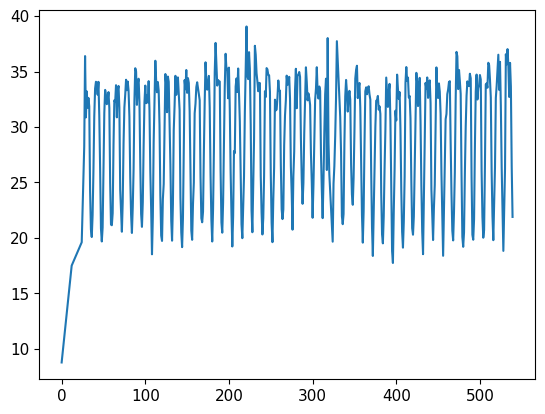

In [122]:
import matplotlib.pyplot as plt

plt.plot(df_HI_2024_interpolated['heat_index_C'])

In [123]:
import pandas as pd

df_district_2024 = pd.read_csv("../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_HI_2024 = pd.DataFrame()
df_HI_2024['date'] = df_monthly_temp['date']
df_HI_2024['temperature'] = df_monthly_temp['temperature(degree C)']
df_HI_2024['humidity'] = df_monthly_hum['humidity']


# Heat Index Function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    if 0.0 <= h <= 1.0:
        h = h * 100.0

    t_f = t_c * 9.0/5.0 + 32.0

    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    hi_c = (hi - 32.0) * 5.0/9.0
    return hi_c


# Calculate Heat Index
df_HI_2024['heat_index_C'] = df_HI_2024.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)


df_HI_2024


,date,temperature,humidity,heat_index_C
6,1980-01-07,10.300000,52.900000,8.766833
7,1980-01-08,10.319211,52.971316,8.789827
8,1980-01-09,10.338421,53.042632,8.812821
9,1980-01-10,10.357632,53.113947,8.835814
10,1980-01-11,10.376842,53.185263,8.858808
...,...,...,...,...
16432,2024-12-27,21.300000,71.500000,21.352500
16433,2024-12-28,20.600000,76.000000,20.700000
16434,2024-12-29,20.900000,75.500000,21.016944
16435,2024-12-30,21.500000,71.800000,21.580333


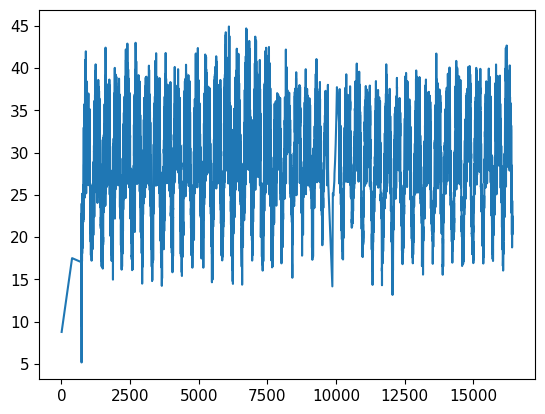

In [124]:
import matplotlib.pyplot as plt

plt.plot(df_HI_2024['heat_index_C'])
# plt.xlim(pd.Timestamp('2014-01-01'))

Calculating heat index with 2025 raw data

In [125]:
# import pandas as pd

# df_district_2025 = pd.read_csv("../2025-dataset/Rangamati_historical_weather_2025.csv")

# df = df_district_2025.copy()
# df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
# df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

# df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
# df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

# df_HI_2025 = pd.DataFrame()
# df_HI_2025['date'] = df_monthly_temp['date']
# df_HI_2025['temperature'] = df_monthly_temp['temperature(degree C)']
# df_HI_2025['humidity'] = df_monthly_hum['humidity']


# # Heat Index Function
# def calculate_heat_index(temperature_c, humidity):

#     t_c = float(temperature_c)
#     h = float(humidity)

#     if 0.0 <= h <= 1.0:
#         h = h * 100.0

#     t_f = t_c * 9.0/5.0 + 32.0

#     hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

#     if hi >= 80.0:
#         T = t_f
#         R = h
#         hi = (-42.379 + 2.04901523*T + 10.14333127*R
#               - 0.22475541*T*R - 6.83783e-3*T**2
#               - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
#               + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

#     hi_c = (hi - 32.0) * 5.0/9.0
#     return hi_c


# # Calculate Heat Index
# df_HI_2025['heat_index_C'] = df_HI_2025.apply(
#     lambda r: calculate_heat_index(r['temperature'], r['humidity']),
#     axis=1
# )


# print(df_HI_2025)


In [126]:
import pandas as pd

df_district_2025 = pd.read_csv("../2025-dataset/Rangamati_historical_weather_2025.csv")

df = df_district_2025.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# Removed .resample('MS').mean() to keep daily granularity
df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.dropna()

# Removed .resample('MS').mean() to keep daily granularity
df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.dropna()

df_HI_2025 = pd.DataFrame()
df_HI_2025['date'] = df_monthly_temp['date']
df_HI_2025['temperature'] = df_monthly_temp['temperature(degree C)']
df_HI_2025['humidity'] = df_monthly_hum['humidity']


# Heat Index Function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    if 0.0 <= h <= 1.0:
        h = h * 100.0

    t_f = t_c * 9.0/5.0 + 32.0

    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    hi_c = (hi - 32.0) * 5.0/9.0
    return hi_c


# Calculate Heat Index
df_HI_2025['heat_index_C'] = df_HI_2025.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)


print(df_HI_2025)

          date  temperature  humidity  heat_index_C
0   2025-01-01         19.1      84.5     19.271944
1   2025-01-02         18.4      87.2     18.572444
2   2025-01-03         18.3      91.1     18.564278
3   2025-01-04         19.4      88.3     19.701167
4   2025-01-05         21.1      82.2     21.411889
..         ...          ...       ...           ...
319 2025-11-16         25.2      70.7     25.621611
320 2025-11-17         25.7      77.0     26.336111
321 2025-11-18         26.1      70.5     26.606389
322 2025-11-19         26.6      69.5     28.169204
323 2025-11-20         24.0      71.7     24.327722

[324 rows x 4 columns]


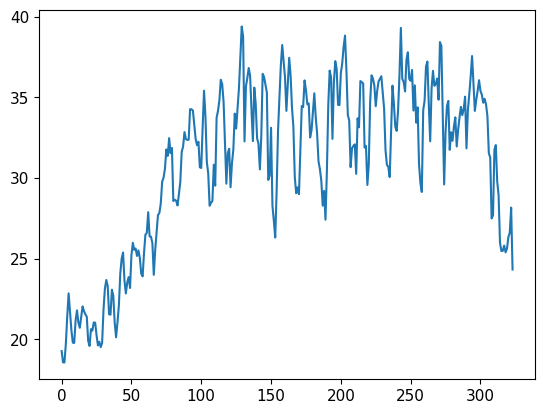

In [127]:
import matplotlib.pyplot as plt
plt.plot(df_HI_2025['heat_index_C'])

 Calculating heat index using predicted temperature and humidity

In [128]:
df_HI = pd.DataFrame()

# Add predicted temperature and humidity
df_HI['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_HI['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values


# Column names
temp_col = 'predicted_temp'
hum_col = 'predicted_humidity'


# Heat Index calculation function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    # If humidity is fraction convert to %
    if 0.0 <= h <= 1.0:
        h = h * 100.0

    # Convert Celsius → Fahrenheit
    t_f = t_c * 9.0/5.0 + 32.0

    # Simple heat index approximation
    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    # Full NOAA/NWS formula
    if hi >= 80.0:
        T = t_f
        R = h

        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    # Convert Fahrenheit → Celsius
    hi_c = (hi - 32.0) * 5.0/9.0

    return hi_c


# Calculate heat index for predictions
df_HI['predicted_heat_index_C'] = df_HI.apply(
    lambda r: calculate_heat_index(r[temp_col], r[hum_col]),
    axis=1
)

# Inspect results

print(df_HI)

    predicted_temp  predicted_humidity  predicted_heat_index_C
0        17.821377           76.514579               17.656951
1        22.059145           69.806988               22.143353
2        26.126484           69.444449               26.607960
3        31.050207           73.114804               38.708339
4        30.328499           78.882099               38.350003
5        30.927353           83.617509               41.928999
6        29.820646           84.117355               38.275099
7        29.651806           84.128398               37.724546
8        29.259247           83.428400               36.296548
9        28.338671           81.332769               33.197863
10       24.518003           77.419732               25.046875
11       20.176893           77.204347               20.266029
12       17.821377           76.514579               17.656951
13       22.059145           69.806988               22.143353
14       26.126484           69.444449               26

## Plotting real vs predicted heat index

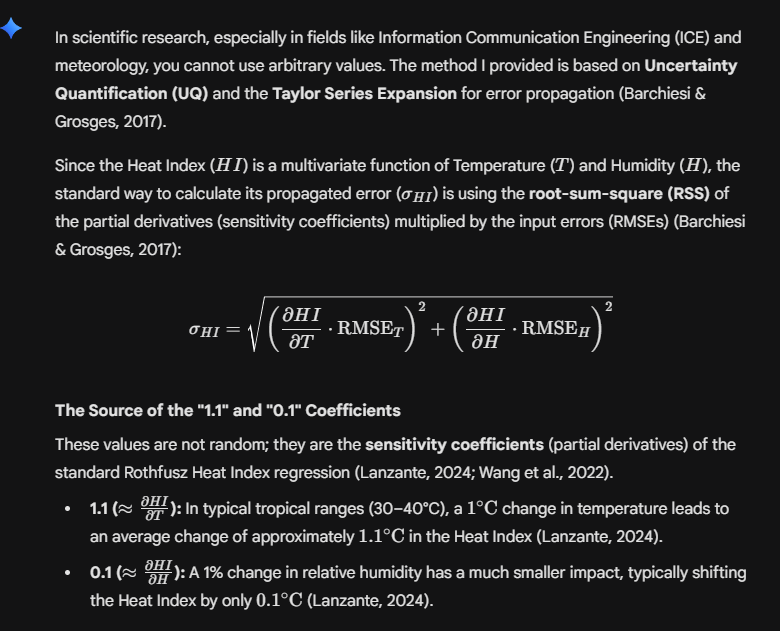

error propagation cloud 

C:\Users\User\AppData\Local\Temp\ipykernel_13972\3527412424.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_HI_pred_plot['upper_95'] = df_HI_pred_plot['predicted_heat_index_C'] + (1.96 * hi_rmse)
C:\Users\User\AppData\Local\Temp\ipykernel_13972\3527412424.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_HI_pred_plot['lower_95'] = df_HI_pred_plot['predicted_heat_index_C'] - (1.96 * hi_rmse)
C:\Users\User\AppData\Local\Temp\ipykernel_13972\3527412424.py:39: SettingWithCopyWarning: 
A value is t

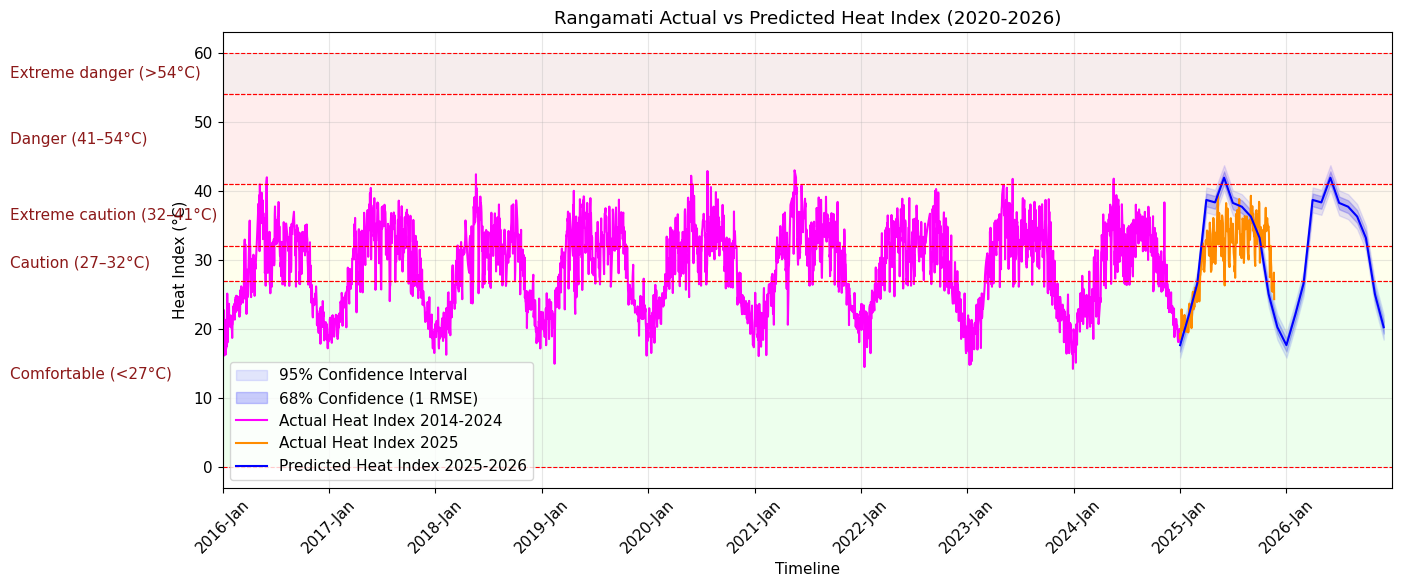

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# --- Ensure datetime index for monthly data ---

df_HI_2024_interpolated = df_HI_2024_interpolated.copy()
df_HI_2024_interpolated['date'] = pd.date_range(start='2014-01-01', periods=len(df_HI_2024_interpolated), freq='MS')
df_HI_2024_interpolated = df_HI_2024_interpolated.set_index('date')

df_HI_2024 = df_HI_2024.copy()
df_HI_2024['date'] = pd.date_range(start='2014-01-01', periods=len(df_HI_2024))
df_HI_2024 = df_HI_2024.set_index('date')

df_HI_2025 = df_HI_2025.copy()
df_HI_2025['date'] = pd.date_range(start='2025-01-01', periods=len(df_HI_2025))
df_HI_2025 = df_HI_2025.set_index('date')

df_HI = df_HI.copy()
df_HI['date'] = pd.date_range(start='2025-01-01', periods=len(df_HI), freq='MS')
df_HI = df_HI.set_index('date')

# --- Filter ranges ---
df_HI_2024_interpolated_plot = df_HI_2024_interpolated.loc['2014-01-01':'2024-12-31']
df_HI_2024_plot = df_HI_2024.loc['2014-01-01':'2024-12-31']
df_HI_2025_plot = df_HI_2025.loc['2025-01-01':'2025-12-31']
df_HI_pred_plot = df_HI.loc['2025-01-01':'2026-12-31']


# --- Define RMSE for Heat Index ---
# Replace this with your actual Heat Index model RMSE
hi_rmse = 0.925 #########################################################################  

# Calculate bounds for the prediction DataFrame
df_HI_pred_plot['upper_95'] = df_HI_pred_plot['predicted_heat_index_C'] + (1.96 * hi_rmse)
df_HI_pred_plot['lower_95'] = df_HI_pred_plot['predicted_heat_index_C'] - (1.96 * hi_rmse)
df_HI_pred_plot['upper_68'] = df_HI_pred_plot['predicted_heat_index_C'] + hi_rmse
df_HI_pred_plot['lower_68'] = df_HI_pred_plot['predicted_heat_index_C'] - hi_rmse

# --- Plot the Confidence Cloud ---

# 95% Confidence Interval (Lighter Blue)
plt.fill_between(df_HI_pred_plot.index, 
                 df_HI_pred_plot['lower_95'], 
                 df_HI_pred_plot['upper_95'], 
                 color='blue', alpha=0.1, label='95% Confidence Interval')

# 68% Confidence Interval (Slightly Darker Blue)
plt.fill_between(df_HI_pred_plot.index, 
                 df_HI_pred_plot['lower_68'], 
                 df_HI_pred_plot['upper_68'], 
                 color='blue', alpha=0.2, label='68% Confidence (1 RMSE)')




# --- Plot actual vs predicted ---

plt.plot(df_HI_2024_plot.index, df_HI_2024_plot['heat_index_C'], 
         label='Actual Heat Index 2014-2024', color='magenta')

plt.plot(df_HI_2025_plot.index, df_HI_2025_plot['heat_index_C'], 
         label='Actual Heat Index 2025', color='darkorange')

plt.plot(df_HI_pred_plot.index, df_HI_pred_plot['predicted_heat_index_C'], 
         label='Predicted Heat Index 2025-2026', color='blue')
# plt.plot(df_HI_2024_interpolated_plot.index, df_HI_2024_interpolated_plot['heat_index_C'],
#          label='Actual monthly interpolated Heat Index 2014-2024', color='black')

# --- Labels and title ---
plt.xlabel('Timeline')
plt.ylabel('Heat Index (°C)')
plt.title('Rangamati Actual vs Predicted Heat Index (2020-2026)')

# --- Heat index bands ---
bands = [
    (0, 27, "Comfortable (<27°C)", (0, 1, 0, 0.07)),        # Green
    (27, 32, "Caution (27–32°C)", (1, 1, 0, 0.07)),          # Yellow
    (32, 41, "Extreme caution (32–41°C)", (1, 0.65, 0, 0.07)), # Orange
    (41, 54, "Danger (41–54°C)", (1, 0, 0, 0.07)),           # Red
    (54, 60, "Extreme danger (>54°C)", (0.5, 0, 0, 0.07))    # Dark Red
]

ax = plt.gca()
for low, high, label, color in bands:
    ax.axhspan(low, high, facecolor=color, edgecolor=None)
    plt.axhline(y=low, color='red', linestyle='--', linewidth=0.8)
    plt.axhline(y=high, color='red', linestyle='--', linewidth=0.8)
    plt.text(
        x=df_HI_2024_plot.index.min(),
        y=(low + high)/2,
        s=label,
        fontsize=11,
        color="maroon",
        va="center",
        ha="left",
        alpha=0.9
    )

# --- X-axis formatting ---
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'))

plt.legend()
plt.tight_layout()
plt.show()

# Wet Bulb

Calculating wet bulb with 1980-2024 raw data

In [130]:
import pandas as pd
import numpy as np

df_district_2024 = pd.read_csv("../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_WB_2024 = pd.DataFrame()
df_WB_2024['date'] = df_monthly_temp['date']
df_WB_2024['temperature'] = df_monthly_temp['temperature(degree C)']
df_WB_2024['humidity'] = df_monthly_hum['humidity']


# Wet Bulb Function (Stull's Equation)
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WB_2024['wet_bulb_C'] = df_WB_2024.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

df_WB_2024

,date,temperature,humidity,wet_bulb_C
0,1980-01-01,10.300000,52.900000,5.628841
1,1980-02-01,10.908333,55.158333,6.375161
2,1980-03-01,11.516667,57.416667,7.132542
3,1980-04-01,12.125000,59.675000,7.900509
4,1980-05-01,12.733333,61.933333,8.678622
...,...,...,...,...
535,2024-08-01,27.706452,89.245161,26.253274
536,2024-09-01,29.086667,83.503333,26.770628
537,2024-10-01,28.490323,81.541935,25.906384
538,2024-11-01,25.836667,73.710000,22.246862


 Calculating wet bulb with 2025 raw data

In [131]:
import pandas as pd
import numpy as np

df_district_2025 = pd.read_csv("../2025-dataset/Rangamati_historical_weather_2025.csv")

df = df_district_2025.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_WB_2025 = pd.DataFrame()
df_WB_2025['date'] = df_monthly_temp['date']
df_WB_2025['temperature'] = df_monthly_temp['temperature(degree C)']
df_WB_2025['humidity'] = df_monthly_hum['humidity']


# Wet Bulb Function (Stull's Equation)
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WB_2025['wet_bulb_C'] = df_WB_2025.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

df_WB_2025.tail(30)

,date,temperature,humidity,wet_bulb_C
0,2025-01-01,20.519355,75.722581,17.489167
1,2025-02-01,23.428571,68.114286,19.216554
2,2025-03-01,27.083871,69.022581,22.734863
3,2025-04-01,28.693333,71.716667,24.639003
4,2025-05-01,29.012903,77.448387,25.802363
5,2025-06-01,28.213333,84.573333,26.079149
6,2025-07-01,28.080645,88.112903,26.459088
7,2025-08-01,28.364516,85.387097,26.343955
8,2025-09-01,29.043333,82.406667,26.567164
9,2025-10-01,28.693548,81.261290,26.061088


Calculating wet bulb using predicted temperature and humidity

In [132]:
df_WB = pd.DataFrame()

# Add predicted temperature and humidity
df_WB['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_WB['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values


# Column names
temp_col = 'predicted_temp'
hum_col = 'predicted_humidity'


def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate wet bulb temperature for predictions
df_WB['predicted_wet_bulb_C'] = df_WB.apply(
    lambda r: calculate_wet_bulb(r[temp_col], r[hum_col]),
    axis=1
)

# Inspect results

print(df_WB)

    predicted_temp  predicted_humidity  predicted_wet_bulb_C
0        17.821377           76.514579             15.024480
1        22.059145           69.806988             18.172856
2        26.126484           69.444449             21.906980
3        31.050207           73.114804             27.067465
4        30.328499           78.882099             27.275117
5        30.927353           83.617509             28.571838
6        29.820646           84.117355             27.573386
7        29.651806           84.128398             27.411133
8        29.259247           83.428400             26.926822
9        28.338671           81.332769             25.729649
10       24.518003           77.419732             21.514174
11       20.176893           77.204347             17.349863
12       17.821377           76.514579             15.024480
13       22.059145           69.806988             18.172856
14       26.126484           69.444449             21.906980
15       31.050207      

## Plotting real vs predicted wet bulb

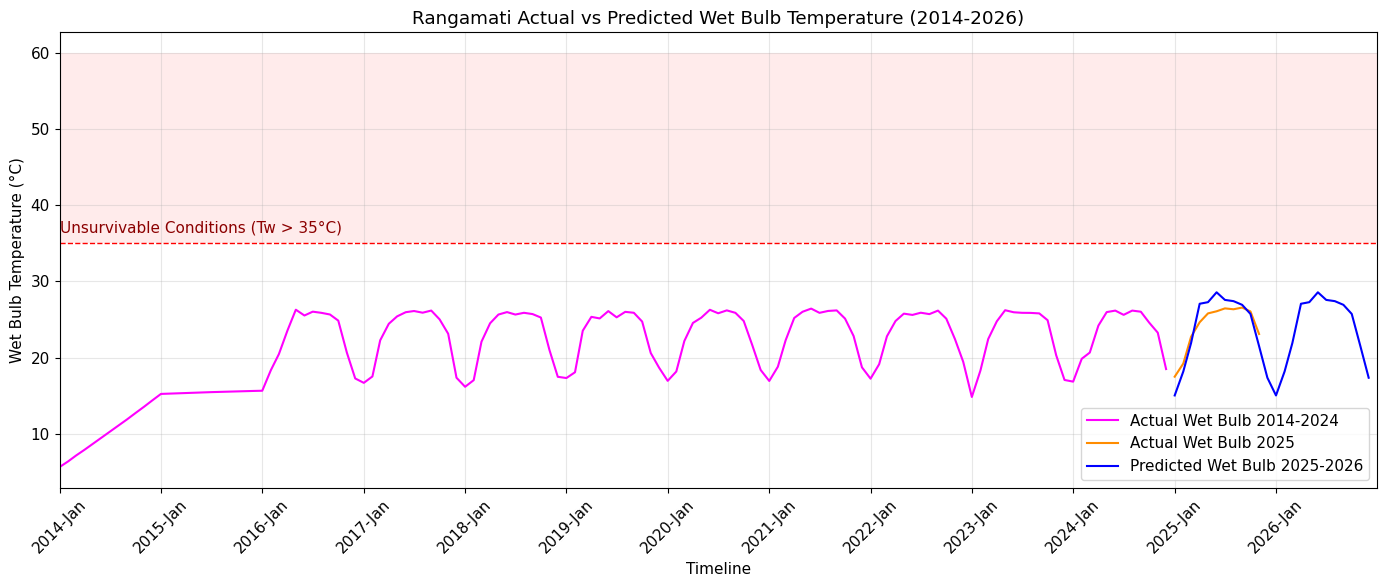

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# --- Ensure datetime index for monthly data ---
df_WB_2024 = df_WB_2024.copy()
df_WB_2024['date'] = pd.date_range(start='2014-01-01', periods=len(df_WB_2024), freq='MS')
df_WB_2024 = df_WB_2024.set_index('date')

df_WB_2025 = df_WB_2025.copy()
df_WB_2025['date'] = pd.date_range(start='2025-01-01', periods=len(df_WB_2025), freq='MS')
df_WB_2025 = df_WB_2025.set_index('date')

df_WB = df_WB.copy()
df_WB['date'] = pd.date_range(start='2025-01-01', periods=len(df_WB), freq='MS')
df_WB = df_WB.set_index('date')

# --- Filter ranges ---
df_WB_2024_plot = df_WB_2024.loc['2014-01-01':'2024-12-31']
df_WB_2025_plot = df_WB_2025.loc['2025-01-01':'2025-12-31']
df_WB_pred_plot = df_WB.loc['2025-01-01':'2026-12-31']

# --- Plot actual vs predicted ---
plt.plot(df_WB_2024_plot.index, df_WB_2024_plot['wet_bulb_C'],
         label='Actual Wet Bulb 2014-2024', color='magenta')

plt.plot(df_WB_2025_plot.index, df_WB_2025_plot['wet_bulb_C'],
         label='Actual Wet Bulb 2025', color='darkorange')

plt.plot(df_WB_pred_plot.index, df_WB_pred_plot['predicted_wet_bulb_C'],
         label='Predicted Wet Bulb 2025-2026', color='blue')

# --- Labels and title ---
plt.xlabel('Timeline')
plt.ylabel('Wet Bulb Temperature (°C)')
plt.title('Rangamati Actual vs Predicted Wet Bulb Temperature (2014-2026)')

# --- Unsuvivable condition band ---
ax = plt.gca()

unsurvivable_threshold = 35

ax.axhspan(unsurvivable_threshold, 60, facecolor=(1,0,0,0.08), edgecolor=None)

plt.axhline(y=unsurvivable_threshold, color='red', linestyle='--', linewidth=1)

plt.text(
    x=df_WB_2024_plot.index.min(),
    y=unsurvivable_threshold + 1,
    s="Unsurvivable Conditions (Tw > 35°C)",
    fontsize=11,
    color="darkred",
    va="bottom",
    ha="left"
)

# --- X-axis formatting ---
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.xlim(pd.Timestamp('2014-01-01'), pd.Timestamp('2026-12-31'))

plt.legend()
plt.tight_layout()
plt.show()

# Wet Bulb Globe Temperature 

Calculating wet bulb globe with 1980-2024 raw data

In [144]:
import pandas as pd
import numpy as np


df = pd.read_csv("../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv")

df['date'] = pd.to_datetime(df[['year', 'month', 'day']])


df = df.set_index('date')

df_monthly = df.resample('MS')[[
    'temperature(degree C)',
    'humidity',
    'solar_radiation'
]].mean()


full_range = pd.date_range(
    start='1980-01-01',
    end='2024-12-01',
    freq='MS'
)

df_monthly = df_monthly.reindex(full_range)


df_monthly = df_monthly.interpolate(method='linear')


df_monthly = df_monthly.reset_index()
df_monthly.rename(columns={
    'index': 'date',
    'temperature(degree C)': 'temperature_C'
}, inplace=True)

def calculate_wet_bulb(T, RH):

    RH = np.where(RH <= 1, RH*100, RH)

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw

df_monthly['wet_bulb_C'] = calculate_wet_bulb(
    df_monthly['temperature_C'],
    df_monthly['humidity']
)


df_monthly['WBGT'] = (
    0.7 * df_monthly['wet_bulb_C']
    + 0.2 * (df_monthly['temperature_C'] + 0.0003 * df_monthly['solar_radiation'])
    + 0.1 * df_monthly['temperature_C']
)


df_WBG_2024 = df_monthly[[
    'date',
    'temperature_C',
    'humidity',
    'solar_radiation',
    'wet_bulb_C',
    'WBGT'
]]

df_WBG_2024

,date,temperature_C,humidity,solar_radiation,wet_bulb_C,WBGT
0,1980-01-01,10.300000,52.900000,NaN,5.628841,NaN
1,1980-02-01,10.908333,55.158333,NaN,6.375161,NaN
2,1980-03-01,11.516667,57.416667,NaN,7.132542,NaN
3,1980-04-01,12.125000,59.675000,NaN,7.900509,NaN
4,1980-05-01,12.733333,61.933333,NaN,8.678622,NaN
...,...,...,...,...,...,...
535,2024-08-01,27.706452,89.245161,121.158065,26.253274,26.696497
536,2024-09-01,29.086667,83.503333,180.176667,26.770628,27.476250
537,2024-10-01,28.490323,81.541935,184.716129,25.906384,26.692648
538,2024-11-01,25.836667,73.710000,187.806667,22.246862,23.335072


Calculating wet bulb globe with 2025 raw data

In [145]:
import pandas as pd
import numpy as np


df_2025 = pd.read_csv("../2025-dataset/Rangamati_historical_weather_2025.csv")

df_2025['date'] = pd.to_datetime(df_2025[['year', 'month', 'day']])


df_2025 = df_2025.set_index('date')

df_monthly_2025 = df_2025.resample('MS')[[
    'temperature(degree C)',
    'humidity',
    'solar_radiation'
]].mean()


full_range = pd.date_range(
    start='2025-01-01',
    end='2025-11-01',
    freq='MS'
)

df_monthly_2025 = df_monthly_2025.reindex(full_range)


df_monthly_2025 = df_monthly_2025.interpolate(method='linear')


df_monthly_2025 = df_monthly_2025.reset_index()
df_monthly_2025.rename(columns={
    'index': 'date',
    'temperature(degree C)': 'temperature_C'
}, inplace=True)

def calculate_wet_bulb(T, RH):

    RH = np.where(RH <= 1, RH*100, RH)

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw

df_monthly_2025['wet_bulb_C'] = calculate_wet_bulb(
    df_monthly_2025['temperature_C'],
    df_monthly_2025['humidity']
)


df_monthly_2025['WBGT'] = (
    0.7 * df_monthly_2025['wet_bulb_C']
    + 0.2 * (df_monthly_2025['temperature_C'] + 0.0003 * df_monthly_2025['solar_radiation'])
    + 0.1 * df_monthly_2025['temperature_C']
)


df_WBG_2025 = df_monthly_2025[[
    'date',
    'temperature_C',
    'humidity',
    'solar_radiation',
    'wet_bulb_C',
    'WBGT'
]]

df_WBG_2025

,date,temperature_C,humidity,solar_radiation,wet_bulb_C,WBGT
0,2025-01-01,20.519355,75.722581,194.003226,17.489167,18.409864
1,2025-02-01,23.428571,68.114286,225.275000,19.216554,20.493676
2,2025-03-01,27.083871,69.022581,254.758065,22.734863,24.054851
3,2025-04-01,28.693333,71.716667,246.376667,24.639003,25.870085
4,2025-05-01,29.012903,77.448387,213.132258,25.802363,26.778313
5,2025-06-01,28.213333,84.573333,149.730000,26.079149,26.728388
6,2025-07-01,28.080645,88.112903,149.825806,26.459088,26.954545
7,2025-08-01,28.364516,85.387097,176.990323,26.343955,26.960743
8,2025-09-01,29.043333,82.406667,191.163333,26.567164,27.321484
9,2025-10-01,28.693548,81.261290,190.325806,26.061088,26.862246


In [146]:
import pandas as pd

predicted_values = [
182.83058633, 220.65346867, 244.89210809, 263.50085314,
236.56627846, 186.09434937, 178.52809989, 158.00012163,
180.89888934, 184.90229464, 179.09802704, 160.90737195,
182.83058633, 220.65346867, 244.89210809, 263.50085314,
236.56627846, 186.09434937, 178.52809989, 158.00012163,
180.89888934, 184.90229464, 179.09802704, 160.90737195
]

# Monthly dates for 2 years starting 2025
dates = pd.date_range(start="2025-01-01", periods=24, freq="MS")

# Create dataframe
df_predicted_solar = pd.DataFrame({
    "date": dates,
    "predicted_solar": predicted_values
})

df_predicted_solar

,date,predicted_solar
0,2025-01-01,182.830586
1,2025-02-01,220.653469
2,2025-03-01,244.892108
3,2025-04-01,263.500853
4,2025-05-01,236.566278
5,2025-06-01,186.094349
6,2025-07-01,178.528100
7,2025-08-01,158.000122
8,2025-09-01,180.898889
9,2025-10-01,184.902295


## Calculating wet bulb globe with predicted values for next 2 years 

In [147]:
import pandas as pd
import numpy as np

# Create dataframe
df_WBG = pd.DataFrame()

# Add date column (recommended for time series)
df_WBG['date'] = df_predicted_solar['date']

# Add predicted variables
df_WBG['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_WBG['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values
df_WBG['predicted_solar'] = df_predicted_solar['predicted_solar'].values


# Wet Bulb Function
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    # Convert RH if given as fraction
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WBG['predicted_wet_bulb_C'] = df_WBG.apply(
    lambda r: calculate_wet_bulb(r['predicted_temp'], r['predicted_humidity']),
    axis=1
)


# Calculate WBGT
# WBGT ≈ 0.7 × Tw + 0.2 × (T + 0.0003 × SR) + 0.1 × T

df_WBG['predicted_WBGT'] = (
    0.7 * df_WBG['predicted_wet_bulb_C']
    + 0.2 * (df_WBG['predicted_temp'] + 0.0003 * df_WBG['predicted_solar'])
    + 0.1 * df_WBG['predicted_temp']
)



df_WBG

,date,predicted_temp,predicted_humidity,predicted_solar,predicted_wet_bulb_C,predicted_WBGT
0,2025-01-01,17.821377,76.514579,182.830586,15.024480,15.874519
1,2025-02-01,22.059145,69.806988,220.653469,18.172856,19.351982
2,2025-03-01,26.126484,69.444449,244.892108,21.906980,23.187525
3,2025-04-01,31.050207,73.114804,263.500853,27.067465,28.278098
4,2025-05-01,30.328499,78.882099,236.566278,27.275117,28.205326
5,2025-06-01,30.927353,83.617509,186.094349,28.571838,29.289658
6,2025-07-01,29.820646,84.117355,178.528100,27.573386,28.258276
7,2025-08-01,29.651806,84.128398,158.000122,27.411133,28.092815
8,2025-09-01,29.259247,83.428400,180.898889,26.926822,27.637403
9,2025-10-01,28.338671,81.332769,184.902295,25.729649,26.523450


## Plotting real vs predicted 

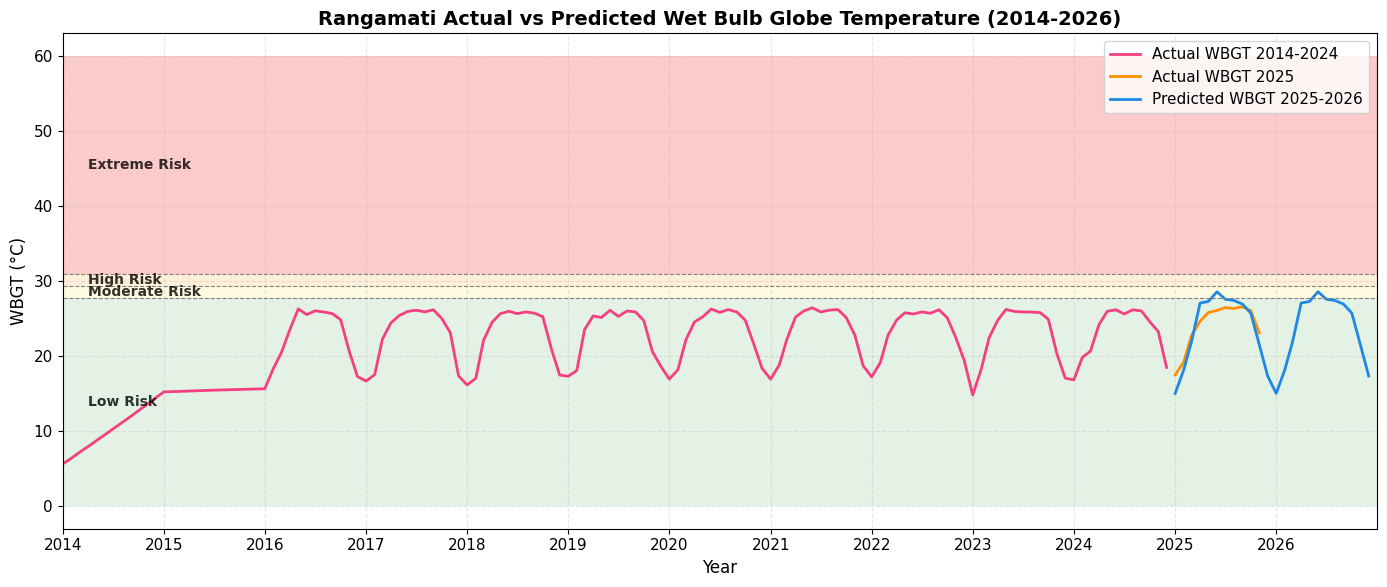

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# --- Ensure datetime index ---
for df, start in zip([df_WBG_2024, df_WBG_2025, df_WBG],
                     ['2014-01-01','2025-01-01','2025-01-01']):
    df['date'] = pd.date_range(start=start, periods=len(df), freq='MS')
    df.set_index('date', inplace=True)

# --- Filter ranges for plotting ---
df_WBG_2024_plot = df_WBG_2024.loc['2014-01-01':'2024-12-31']
df_WBG_2025_plot = df_WBG_2025.loc['2025-01-01':'2025-12-31']
df_WBG_pred_plot = df_WBG.loc['2025-01-01':'2026-12-31']

# --- Plot actual vs predicted WBGT ---
plt.plot(df_WBG_2024_plot.index, df_WBG_2024_plot['wet_bulb_C'],
         label='Actual WBGT 2014-2024', color="#F53F82", linewidth=2)

plt.plot(df_WBG_2025_plot.index, df_WBG_2025_plot['wet_bulb_C'],
         label='Actual WBGT 2025', color='#FF8F00', linewidth=2)

plt.plot(df_WBG_pred_plot.index, df_WBG_pred_plot['predicted_wet_bulb_C'],
         label='Predicted WBGT 2025-2026', color='#1E88E5', linewidth=2)

# --- Risk category bands with labels ---
ax = plt.gca()
bands = [
    (0, 27.8, "Low Risk", "#A5D6A7"),
    (27.8, 29.4, "Moderate Risk", "#FFF59D"),
    (29.4, 31, "High Risk", "#FFCC80"),
    (31, 60, "Extreme Risk", "#EF5350")
]

for start, end, label, color in bands:
    ax.axhspan(start, end, facecolor=color, alpha=0.3)
    # Add text label inside the band
    y_pos = start + (end - start)/2
    ax.text(df_WBG_2024_plot.index[3], y_pos, label,
            fontsize=10, fontweight='bold', color='black', alpha=0.8, va='center')

# --- Threshold lines ---
thresholds = [27.8, 29.4, 31]
for t in thresholds:
    plt.axhline(y=t, color='gray', linestyle='--', linewidth=0.8)

# --- Labels, title, legend ---
plt.xlabel('Year', fontsize=12)
plt.ylabel('WBGT (°C)', fontsize=12)
plt.title('Rangamati Actual vs Predicted Wet Bulb Globe Temperature (2014-2026)', fontsize=14, fontweight='bold')

plt.legend(frameon=True, fontsize=11)

# --- X-axis formatting ---
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

plt.grid(alpha=0.3, linestyle='--')
plt.xlim(pd.Timestamp('2014-01-01'), pd.Timestamp('2026-12-31'))

plt.tight_layout()
plt.show()

## Calculating Heatstroke Risk

Calculating heatstroke risk using 1980-2024 raw data

In [137]:
import pandas as pd
import numpy as np

# --- Load datasets ---
df_district_2024 = pd.read_csv("../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# --- Monthly resampling and interpolation ---
df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().interpolate()
df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().interpolate()

# --- Heat Index Calculation ---
df_HI_2024 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_heat_index(temperature_c, humidity):
    t_c = float(temperature_c)
    h = float(humidity)
    if 0.0 <= h <= 1.0:
        h = h * 100.0
    t_f = t_c * 9.0/5.0 + 32.0
    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))
    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)
    return (hi - 32.0) * 5.0/9.0

df_HI_2024['heat_index_C'] = df_HI_2024.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)

# --- Wet Bulb Calculation (Stull) ---
df_WB_2024 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_wet_bulb(T, RH):
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0
    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )
    return Tw

df_WB_2024['wet_bulb_C'] = df_WB_2024.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

# --- Ensure full 1980-2024 monthly range ---
date_range = pd.date_range(start='1980-01-01', end='2024-12-01', freq='MS')

df_HI_2024 = df_HI_2024.set_index('date').reindex(date_range).interpolate().reset_index()
df_HI_2024.rename(columns={'index':'date'}, inplace=True)

df_WB_2024 = df_WB_2024.set_index('date').reindex(date_range).interpolate().reset_index()
df_WB_2024.rename(columns={'index':'date'}, inplace=True)

# --- Merge datasets ---
df_heatstress_2024 = pd.merge(
    df_HI_2024[['date', 'heat_index_C']],
    df_WB_2024[['date', 'wet_bulb_C']],
    on='date'
)

# --- Heatstroke Risk Function ---
def calculate_heatstroke_risk(heat_index_c, wet_bulb_c):
    HI_F = heat_index_c * 9/5 + 32  # Heat Index in Fahrenheit
    beta0 = -18
    beta1 = 0.15
    risk_hi = 1 / (1 + np.exp(-(beta0 + beta1 * HI_F)))

    if wet_bulb_c >= 35:
        wb_factor = 1.0  # unsurvivable
    elif wet_bulb_c >= 30:
        wb_factor = 0.8  # extreme
    elif wet_bulb_c >= 27:
        wb_factor = 0.5  # moderate
    else:
        wb_factor = 0.2  # low

    risk = risk_hi * wb_factor
    return min(risk, 1)

df_heatstress_2024['heatstroke_risk'] = df_heatstress_2024.apply(
    lambda r: calculate_heatstroke_risk(r['heat_index_C'], r['wet_bulb_C']),
    axis=1
)

#df_heatstress_2024['unsurvivable_flag'] = df_heatstress_2024['wet_bulb_C'] > 35


df_heatstress_2024

,date,heat_index_C,wet_bulb_C,heatstroke_risk
0,1980-01-01,8.766833,5.628841,0.000004
1,1980-02-01,9.494968,6.375161,0.000005
2,1980-03-01,10.223102,7.132542,0.000006
3,1980-04-01,10.951236,7.900509,0.000007
4,1980-05-01,11.679370,8.678622,0.000009
...,...,...,...,...
535,2024-08-01,32.714449,26.253274,0.002506
536,2024-09-01,35.785358,26.770628,0.005650
537,2024-10-01,33.647224,25.906384,0.003212
538,2024-11-01,26.400539,22.246862,0.000460


## 2025 raw data

In [138]:
import pandas as pd
import numpy as np

# --- Load datasets ---
df_district_2025 = pd.read_csv("../2025-dataset/Rangamati_historical_weather_2025.csv")

df = df_district_2025.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# --- Monthly resampling and interpolation ---
df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().interpolate()
df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().interpolate()

# --- Heat Index Calculation ---
df_HI_2025 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_heat_index(temperature_c, humidity):
    t_c = float(temperature_c)
    h = float(humidity)
    if 0.0 <= h <= 1.0:
        h = h * 100.0
    t_f = t_c * 9.0/5.0 + 32.0
    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))
    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)
    return (hi - 32.0) * 5.0/9.0

df_HI_2025['heat_index_C'] = df_HI_2025.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)

# --- Wet Bulb Calculation (Stull) ---
df_WB_2025 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_wet_bulb(T, RH):
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0
    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )
    return Tw

df_WB_2025['wet_bulb_C'] = df_WB_2025.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

date_range = pd.date_range(start='2025-01-01', end='2025-11-01', freq='MS')

df_HI_2025 = df_HI_2025.set_index('date').reindex(date_range).interpolate().reset_index()
df_HI_2025.rename(columns={'index':'date'}, inplace=True)

df_WB_2025 = df_WB_2025.set_index('date').reindex(date_range).interpolate().reset_index()
df_WB_2025.rename(columns={'index':'date'}, inplace=True)

# --- Merge datasets ---
df_heatstress_2025 = pd.merge(
    df_HI_2025[['date', 'heat_index_C']],
    df_WB_2025[['date', 'wet_bulb_C']],
    on='date'
)

# --- Heatstroke Risk Function ---
def calculate_heatstroke_risk(heat_index_c, wet_bulb_c):
    HI_F = heat_index_c * 9/5 + 32  # Heat Index in Fahrenheit
    beta0 = -18
    beta1 = 0.15
    risk_hi = 1 / (1 + np.exp(-(beta0 + beta1 * HI_F)))

    if wet_bulb_c >= 35:
        wb_factor = 1.0  # unsurvivable
    elif wet_bulb_c >= 30:
        wb_factor = 0.8  # extreme
    elif wet_bulb_c >= 27:
        wb_factor = 0.5  # moderate
    else:
        wb_factor = 0.2  # low

    risk = risk_hi * wb_factor
    return min(risk, 1)

df_heatstress_2025['heatstroke_risk'] = df_heatstress_2025.apply(
    lambda r: calculate_heatstroke_risk(r['heat_index_C'], r['wet_bulb_C']),
    axis=1
)

#df_heatstress_2025['unsurvivable_flag'] = df_heatstress_2025['wet_bulb_C'] > 35


df_heatstress_2025

,date,heat_index_C,wet_bulb_C,heatstroke_risk
0,2025-01-01,20.604047,17.489167,0.000096
1,2025-02-01,23.605524,19.216554,0.000217
2,2025-03-01,28.913394,22.734863,0.000905
3,2025-04-01,32.362743,24.639003,0.002281
4,2025-05-01,34.230855,25.802363,0.003750
5,2025-06-01,33.429022,26.079149,0.003031
6,2025-07-01,33.665844,26.459088,0.003228
7,2025-08-01,34.018578,26.343955,0.003545
8,2025-09-01,35.401696,26.567164,0.005108
9,2025-10-01,34.153093,26.061088,0.003673


## Calculating using predicted heat index and wet bulb

In [139]:
import pandas as pd
import numpy as np

# --- Prepare predicted dataframe ---
df_HI = pd.DataFrame()
df_HI['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_HI['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values

# --- Create date column with exact length matching ---
num_rows = len(df_HI)
date_range = pd.date_range(start='2025-01-01', periods=num_rows, freq='MS')
df_HI['date'] = date_range

# --- Heat Index calculation ---
def calculate_heat_index(temperature_c, humidity):
    t_c = float(temperature_c)
    h = float(humidity)
    # Ensure humidity is in %
    if 0.0 <= h <= 1.0:
        h = h * 100.0
    # Convert Celsius to Fahrenheit
    t_f = t_c * 9/5 + 32
    # Simple heat index formula
    hi = 0.5 * (t_f + 61 + ((t_f - 68) * 1.2) + (h * 0.094))
    if hi >= 80:
        T, R = t_f, h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)
    # Convert back to Celsius
    return (hi - 32) * 5/9

df_HI['heat_index_C'] = df_HI.apply(
    lambda r: calculate_heat_index(r['predicted_temp'], r['predicted_humidity']),
    axis=1
)

# --- Wet Bulb calculation ---
def calculate_wet_bulb(T, RH):
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0
    Tw = (T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
          + np.arctan(T + RH)
          - np.arctan(RH - 1.676331)
          + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
          - 4.686035)
    return Tw

df_HI['wet_bulb_C'] = df_HI.apply(
    lambda r: calculate_wet_bulb(r['predicted_temp'], r['predicted_humidity']),
    axis=1
)

# --- Heatstroke risk calculation ---
def calculate_heatstroke_risk(heat_index_c, wet_bulb_c):
    HI_F = heat_index_c * 9/5 + 32  # Convert to Fahrenheit for risk formula
    beta0 = -18
    beta1 = 0.15
    risk_hi = 1 / (1 + np.exp(-(beta0 + beta1 * HI_F)))
    # Wet bulb adjustment factor
    if wet_bulb_c >= 35:
        wb_factor = 1.0
    elif wet_bulb_c >= 30:
        wb_factor = 0.8
    elif wet_bulb_c >= 27:
        wb_factor = 0.5
    else:
        wb_factor = 0.2
    risk = risk_hi * wb_factor
    return min(risk, 1)

df_HI['heatstroke_risk'] = df_HI.apply(
    lambda r: calculate_heatstroke_risk(r['heat_index_C'], r['wet_bulb_C']),
    axis=1
)

# --- Final dataframe ---
df_heatstress = df_HI[['date', 'heat_index_C', 'wet_bulb_C', 'heatstroke_risk']]
df_heatstress

,date,heat_index_C,wet_bulb_C,heatstroke_risk
0,2025-01-01,17.656951,15.024480,0.000044
1,2025-02-01,22.143353,18.172856,0.000146
2,2025-03-01,26.607960,21.906980,0.000487
3,2025-04-01,38.708339,27.067465,0.030079
4,2025-05-01,38.350003,27.275117,0.027457
5,2025-06-01,41.928999,28.571838,0.066242
6,2025-07-01,38.275099,27.573386,0.026937
7,2025-08-01,37.724546,27.411133,0.023390
8,2025-09-01,36.296548,26.926822,0.006460
9,2025-10-01,33.197863,25.729649,0.002850


# Heat Stroke

C:\Users\User\AppData\Local\Temp\ipykernel_13972\2042915947.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heatstress['date'] = pd.to_datetime(df_heatstress['date'])
C:\Users\User\AppData\Local\Temp\ipykernel_13972\2042915947.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heatstress['Heat_Severity'] = df_heatstress['heat_index_C'].apply(categorize_risk)


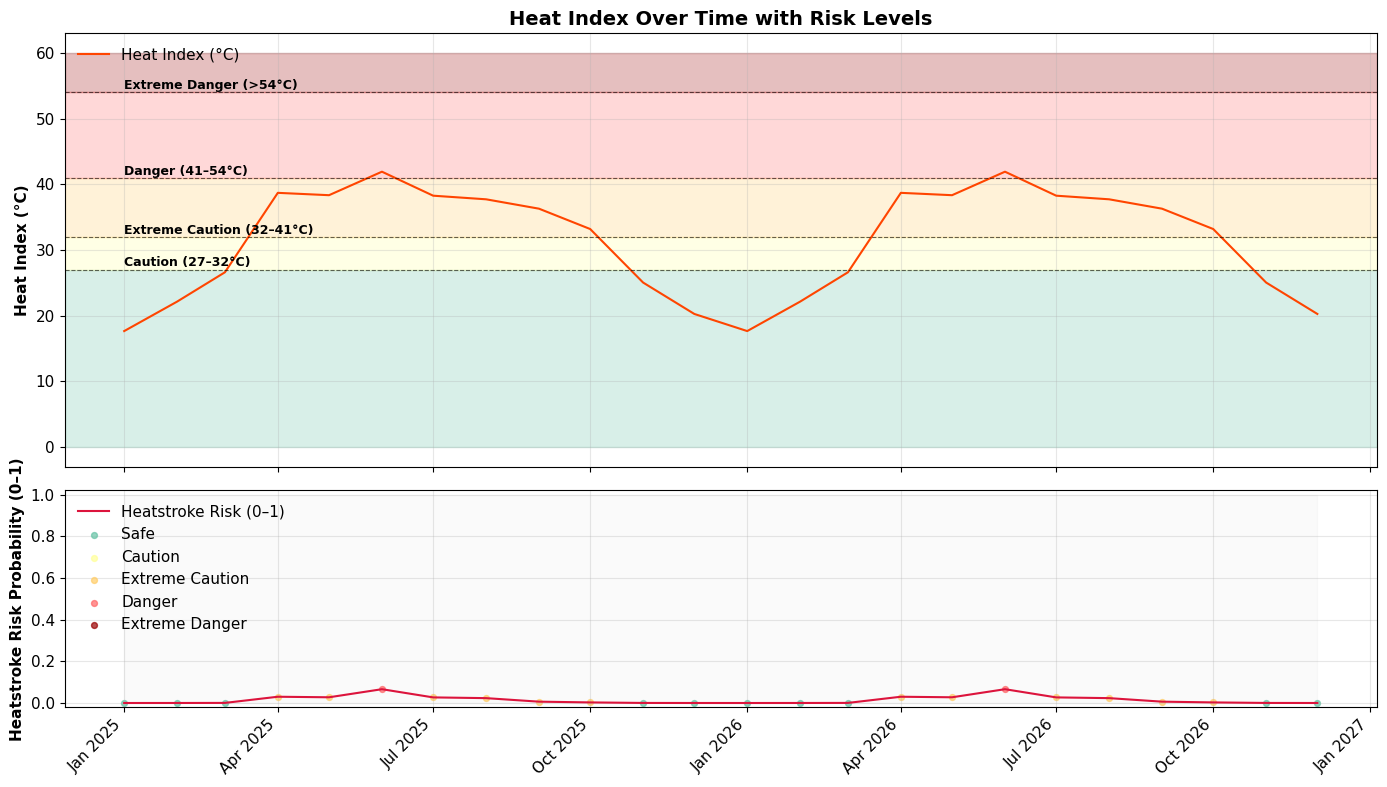

In [154]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# --- Convert date column ---
df_heatstress['date'] = pd.to_datetime(df_heatstress['date'])

# --- Categorize Heat Severity based on NOAA thresholds ---
def categorize_risk(hi_c):
    if hi_c > 54:           # Extreme danger (>54°C)
        return 'Extreme Danger'
    elif hi_c > 41:         # Danger (41–54°C)
        return 'Danger'
    elif hi_c > 32:         # Extreme caution (32–41°C)
        return 'Extreme Caution'
    elif hi_c > 27:         # Caution (27–32°C)
        return 'Caution'
    else:
        return 'Safe'

df_heatstress['Heat_Severity'] = df_heatstress['heat_index_C'].apply(categorize_risk)

# --- Color palette for categories ---
palette = {
    'Safe':'#66c2a5',              # Green
    'Caution':'#ffff99',           # Yellow
    'Extreme Caution':'#ffcc66',   # Orange
    'Danger':'#ff6666',            # Red
    'Extreme Danger':'#990000'     # Dark Red
}

# --- Plot setup ---
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,8), sharex=True, gridspec_kw={'height_ratios':[2,1]})
plt.rcParams.update({'font.size': 11})

# --- Heat Index plot (ax1) ---
ax1.plot(df_heatstress['date'], df_heatstress['heat_index_C'], color='orangered', lw=1.5, label='Heat Index (°C)')

# --- Add NOAA heat index bands as shaded background ---
bands = [
    (0, 27, '#66c2a5', 'Safe (<27°C)'),
    (27, 32, '#ffff99', 'Caution (27–32°C)'),
    (32, 41, '#ffcc66', 'Extreme Caution (32–41°C)'),
    (41, 54, '#ff6666', 'Danger (41–54°C)'),
    (54, 60, '#990000', 'Extreme Danger (>54°C)')
]

for start, end, color, label in bands:
    ax1.axhspan(start, end, color=color, alpha=0.25)

# --- Add threshold lines and labels ---
for start, end, color, label in bands[1:]:
    ax1.axhline(start, color='k', lw=0.8, ls='--', alpha=0.6)
    ax1.text(df_heatstress['date'].iloc[0], start + 0.5, label, fontsize=9, color='k', weight='bold')

ax1.set_ylabel('Heat Index (°C)', weight='bold')
ax1.set_title('Heat Index Over Time with Risk Levels', weight='bold', fontsize=14)
ax1.grid(alpha=0.3)
ax1.legend(loc='upper left', frameon=False)

# --- Heatstroke risk plot (ax2) ---
ax2.fill_between(df_heatstress['date'], 0, 1, color='lightgrey', alpha=0.1)  # subtle background
ax2.plot(df_heatstress['date'], df_heatstress['heatstroke_risk'], color='crimson', lw=1.5, label='Heatstroke Risk (0–1)')

# Color-coded scatter points
for severity, color in palette.items():
    subset = df_heatstress[df_heatstress['Heat_Severity'] == severity]
    ax2.scatter(subset['date'], subset['heatstroke_risk'], s=18, color=color, label=severity, alpha=0.7)

ax2.set_ylabel('Heatstroke Risk Probability (0–1)', weight='bold')
ax2.set_ylim(-0.02,1.02)
ax2.grid(alpha=0.3)
ax2.legend(loc='upper left', frameon=False)

# --- X-axis formatting ---
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()